In [3]:
import numpy as np 
import requests
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

# Question 1

In [4]:
def simulate_data():
    n = 100
    x = np.random.uniform(0, 1, n)      # runif(n)
    s = x**2
    y = 3*x + np.random.normal(0, s, n)
    return n, x, s, y

In [5]:
betas_ols = []
betas_wls = []
betas_wls_est = []

for i in range(1000):

    n, x, s, y = simulate_data()
    # x_sm = sm.add_constant(x)
    x_sm = x

    model_ols = sm.OLS(y, x_sm).fit()

    # print(model_ols.params)
    model_wls = sm.WLS(y, x_sm, weights=(1/(s**2))).fit()

    residuals = model_ols.resid
    u = np.log(residuals ** 2)
    tmp = lowess(u, x, frac=0.3, return_sorted=False)
    s2 = np.exp(tmp)
    w_est = 1/s2
    # print(w_est)

    model_wls_est = sm.WLS(y, x_sm, weights=w_est).fit()

    betas_ols.append(model_ols.params[0])
    betas_wls.append(model_wls.params[0])
    betas_wls_est.append(model_wls_est.params[0])

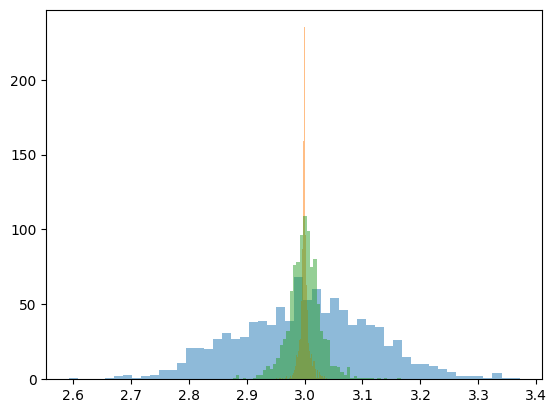

In [6]:
num_bins = 50
plt.hist(betas_ols, bins=num_bins, alpha=0.5)
plt.hist(betas_wls, bins=num_bins, alpha=0.5)
plt.hist(betas_wls_est, bins=num_bins, alpha=0.5)
plt.show()

Variance is a lot lower when using WLS w estimates compared to OLS

# Question 2

In [7]:
df = pd.read_csv("allshoots.csv")

df["Type"] = df["Type"].astype("category")

# df = df.drop(index=[2, 34, 51])

print(df.head())

   Day   n   ybar    SD Type
0    0   5  10.00  0.00    0
1    6   5  11.00  0.72    0
2    9   5  10.00  0.72    0
3   19  11  13.36  1.03    0
4   27   7  14.29  0.95    0


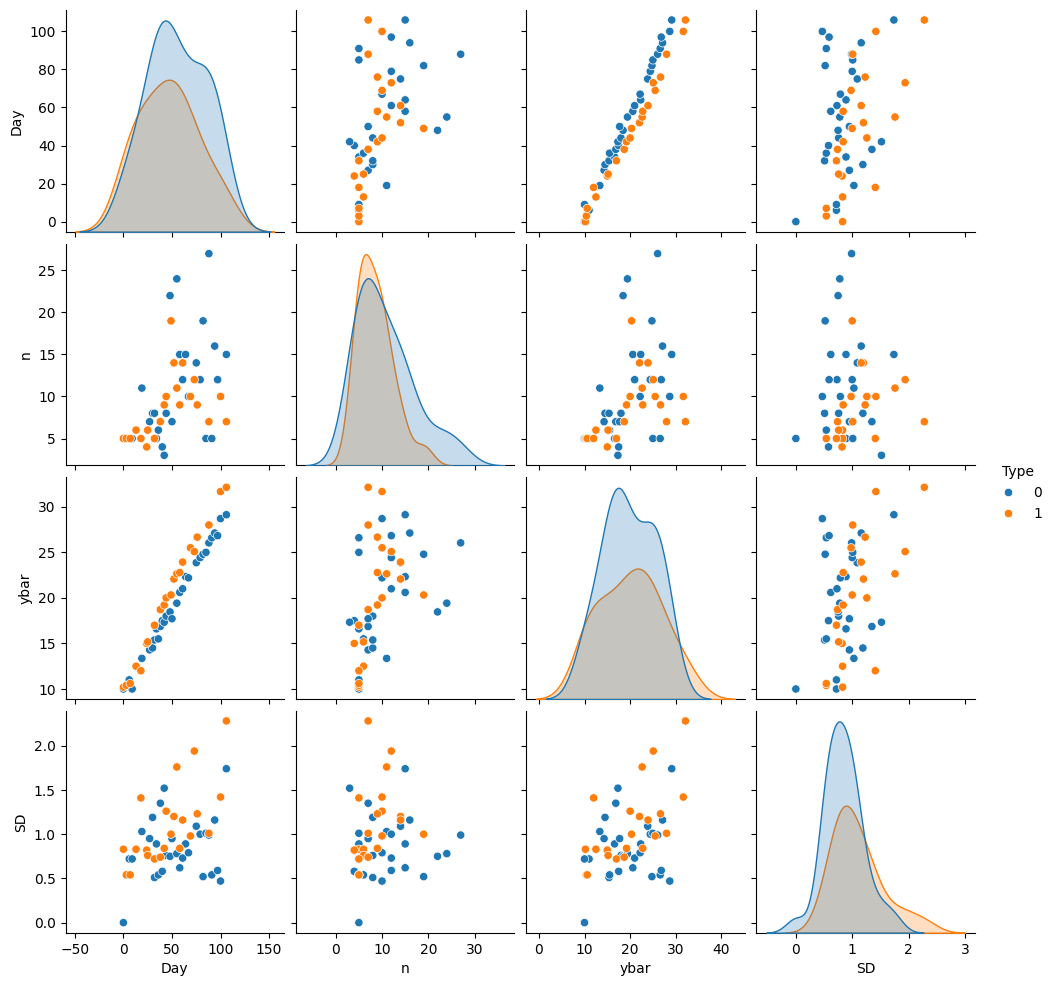

In [8]:
sns.pairplot(df, hue="Type")
plt.show()

No, the relationship between ybar and Day looks linear for both categories

In [9]:
model = smf.ols("ybar ~ Day + C(Type) + Day:Type", data=df).fit()
print(model.summary())
print(model.conf_int(alpha=0.05))

                            OLS Regression Results                            
Dep. Variable:                   ybar   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                     1741.
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           5.91e-49
Time:                        22:08:37   Log-Likelihood:                -44.417
No. Observations:                  52   AIC:                             96.83
Df Residuals:                      48   BIC:                             104.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         9.4759      0.231     41.025

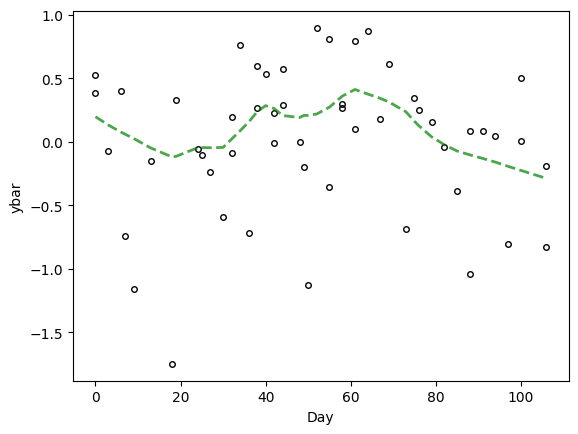

In [10]:
residuals = model.resid

smooth = lowess(residuals, df["Day"], frac=0.3) 

plt.plot(df["Day"], residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
plt.xlabel("Day")
plt.ylabel("ybar")
plt.show()

In [11]:
influence = model.get_influence()
studentised_residuals = influence.resid_studentized_external

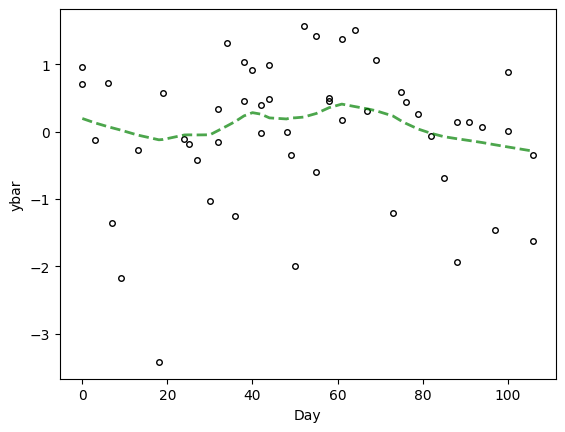

In [12]:
plt.plot(df["Day"], studentised_residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
plt.xlabel("Day")
plt.ylabel("ybar")
plt.show()

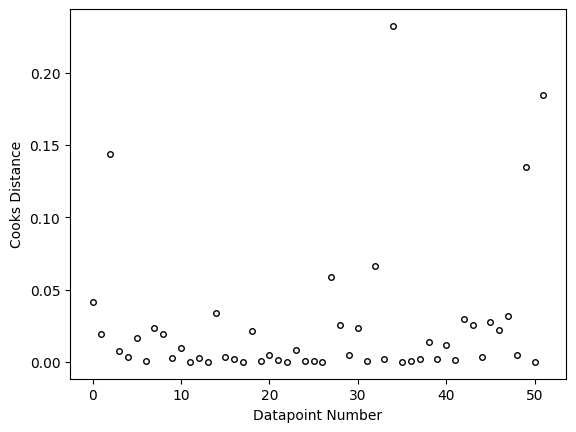

In [13]:
cookd, _ = influence.cooks_distance
indices = range(len(df))

plt.plot(indices, cookd, 'o', markersize=4, fillstyle='none', color='black')
# plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
plt.xlabel("Datapoint Number")
plt.ylabel("Cooks Distance")
plt.show()

In [14]:
# df_new = df.drop(index=[2, 34, 51])

In [17]:
model = smf.wls("ybar ~ Day + C(Type) + Day:Type", data=df, weights=df["n"]).fit()
print(model.summary())
print(model.conf_int(alpha=0.05))

                            WLS Regression Results                            
Dep. Variable:                   ybar   R-squared:                       0.991
Model:                            WLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                     1695.
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.12e-48
Time:                        22:11:30   Log-Likelihood:                -42.529
No. Observations:                  52   AIC:                             93.06
Df Residuals:                      48   BIC:                             100.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         9.4884      0.239     39.764

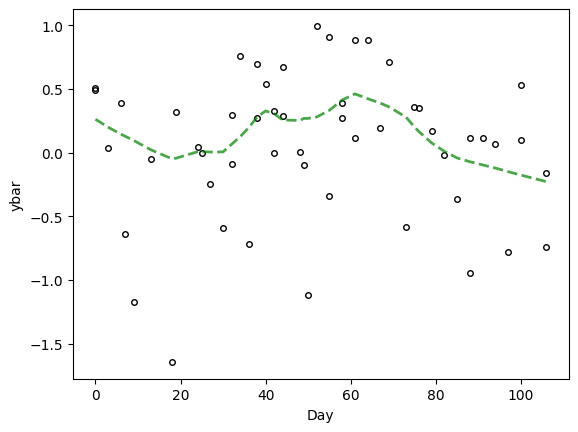

In [16]:
residuals = model.resid

smooth = lowess(residuals, df["Day"], frac=0.3) 

plt.plot(df["Day"], residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
plt.xlabel("Day")
plt.ylabel("ybar")
plt.show()